In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [3]:
df.shape


(103088, 31)

In [4]:
df['Class'].value_counts()

,count
Class,
0.0,102855
1.0,232


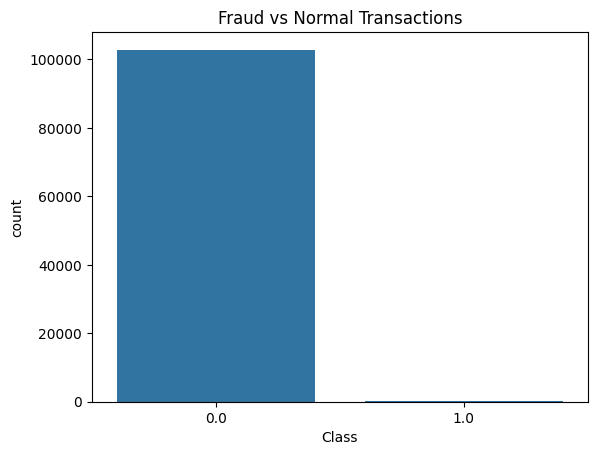

In [25]:
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

In [27]:
df = df.dropna(subset=["Class"])

In [29]:
scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(df[['Amount']])
df.drop(['Time'], axis=1, inplace=True,errors='ignore')

In [30]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [33]:
fraud = df[df.Class == 1]
normal = df[df.Class == 0].sample(len(fraud), random_state=42)

balanced_df = pd.concat([fraud, normal])

In [34]:
balanced_df = balanced_df.sample(frac=1, random_state=42)

In [35]:
X_bal = balanced_df.drop("Class", axis=1)
y_bal = balanced_df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42
)

In [36]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

In [37]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [38]:
print("Logistic Regression Results")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
[[43  0]
 [ 7 43]]
              precision    recall  f1-score   support

         0.0       0.86      1.00      0.92        43
         1.0       1.00      0.86      0.92        50

    accuracy                           0.92        93
   macro avg       0.93      0.93      0.92        93
weighted avg       0.94      0.92      0.92        93



In [39]:
print("Random Forest Results")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Results
[[43  0]
 [ 8 42]]
              precision    recall  f1-score   support

         0.0       0.84      1.00      0.91        43
         1.0       1.00      0.84      0.91        50

    accuracy                           0.91        93
   macro avg       0.92      0.92      0.91        93
weighted avg       0.93      0.91      0.91        93



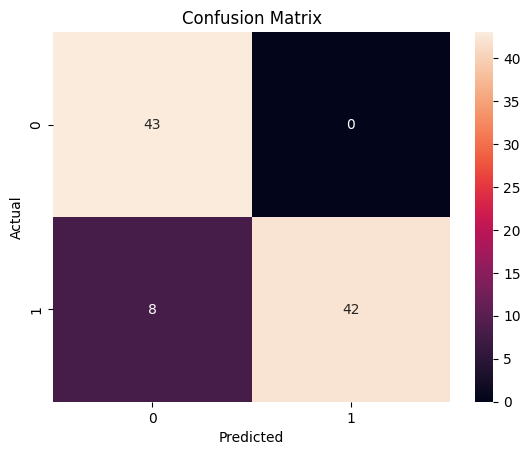

In [40]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [41]:
from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.9247311827956989


In [42]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.9139784946236559


In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

         0.0       0.84      1.00      0.91        43
         1.0       1.00      0.84      0.91        50

    accuracy                           0.91        93
   macro avg       0.92      0.92      0.91        93
weighted avg       0.93      0.91      0.91        93

